In [30]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    BertForSequenceClassification,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

In [ ]:
# Load data from huggingface
dataset = load_dataset("PolyAI/banking77")

print("Original dataset:")
print(dataset)

Using the latest cached version of the dataset since PolyAI/banking77 couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at /root/.cache/huggingface/datasets/PolyAI___banking77/default/1.1.0/17ffc2ed47c2ed928bee64127ff1dbc97204cb974c2f980becae7c864007aed9 (last modified on Mon Oct  5 16:20:05 2026).


Original dataset:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 10003
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3080
    })
})


In [ ]:
# Set hyper-parameters

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

MODEL_NAME = "bert-base-uncased"

NUM_LABELS = 77
MAX_LENGTH = 128

BATCH_SIZE = 32
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

NUM_EPOCHS = 5
WARMUP_RATIO = 0.1

MLP_HIDDEN_SIZE = 256
DROPOUT = 0.2

VALIDATION_RATIO = 0.15

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

Device: cuda


In [ ]:
# Create validation Set. Original Banking77 only provides train and test sets. Split validation from the original training set.

train_val_split = dataset["train"].train_test_split(
    test_size=VALIDATION_RATIO,
    seed=SEED,
    stratify_by_column="label"
)

dataset["train"] = train_val_split["train"]
dataset["validation"] = train_val_split["test"]

print("\nDataset after train/validation split:")
print(dataset)

print("\nTrain size:", len(dataset["train"]))
print("Validation size:", len(dataset["validation"]))
print("Test size:", len(dataset["test"]))


Dataset after train/validation split:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8502
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3080
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1501
    })
})

Train size: 8502
Validation size: 1501
Test size: 3080


In [ ]:
# Build label mapping structure

label_names = dataset["train"].features["label"].names

label2meaning = {
    i: label_name
    for i, label_name in enumerate(label_names)
}

print("\nExample label mapping:")
for i in range(5):
    print(i, "->", label2meaning[i])


Example label mapping:
0 -> activate_my_card
1 -> age_limit
2 -> apple_pay_or_google_pay
3 -> atm_support
4 -> automatic_top_up


In [ ]:
# Initialize tokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

tokenized_dataset = dataset.map(tokenize_function, batched=True)

tokenized_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

Map:   0%|          | 0/8502 [00:00<?, ? examples/s]

Map:   0%|          | 0/3080 [00:00<?, ? examples/s]

Map:   0%|          | 0/1501 [00:00<?, ? examples/s]

In [36]:
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 8502
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3080
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1501
    })
})

In [ ]:
# Dynamic padding and initialize dataLoaders

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")

train_loader = DataLoader(tokenized_dataset["train"], batch_size=BATCH_SIZE, shuffle=True,  collate_fn=data_collator)
val_loader   = DataLoader(tokenized_dataset["validation"], batch_size=BATCH_SIZE, shuffle=False, collate_fn=data_collator)
test_loader  = DataLoader(tokenized_dataset["test"], batch_size=BATCH_SIZE, shuffle=False, collate_fn=data_collator)

In [ ]:
# Inspect a batch to verify the data preprocessing

batch = next(iter(train_loader))

print("\nBatch shapes:")

for key, value in batch.items():
    print(key, value.shape)

print("\nExample tokenized sentence:")
print(
    tokenizer.convert_ids_to_tokens(
        batch["input_ids"][0]
    )
)



Batch shapes:
input_ids torch.Size([32, 43])
attention_mask torch.Size([32, 43])
labels torch.Size([32])

Example tokenized sentence:
['[CLS]', 'are', 'there', 'only', 'certain', 'atm', 'machines', 'where', 'i', 'can', 'use', 'this', 'card', '?', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


In [ ]:
# Create an instance of BERT classification model
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)

model = model.to(DEVICE)

print("\nModel:")
print(model)

# Parameter count

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Model:
BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm

In [ ]:
# Initialize optimizer
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Initialize learning rate scheduler

num_training_steps = len(train_loader) * NUM_EPOCHS
num_warmup_steps = int(WARMUP_RATIO * num_training_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=num_warmup_steps, num_training_steps=num_training_steps
)

print("\nTraining steps:", num_training_steps)
print("Warmup steps:", num_warmup_steps)

criterion = nn.CrossEntropyLoss()


Training steps: 1330
Warmup steps: 133


In [ ]:
# Define evaluation function

def evaluate(model, data_loader, criterion):
    model.eval()

    total_loss = 0.0
    all_labels, all_predictions = [], []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()
            predictions = torch.argmax(logits, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(all_labels, all_predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_predictions, average="macro", zero_division=0
    )

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "labels": np.array(all_labels),
        "predictions": np.array(all_predictions)
    }

In [ ]:
# Training

history = {
    "train_loss": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": []
}

best_val_f1 = -1.0

for epoch in range(NUM_EPOCHS):
    model.train()
    total_train_loss = 0.0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{NUM_EPOCHS}")

    for batch in progress_bar:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_train_loss += loss.item()

        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

    avg_train_loss = total_train_loss / len(train_loader)

    # Validation
    val_results = evaluate(model, val_loader, criterion)

    # Save metrics
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(val_results["loss"])
    history["val_accuracy"].append(val_results["accuracy"])
    history["val_precision"].append(val_results["precision"])
    history["val_recall"].append(val_results["recall"])
    history["val_f1"].append(val_results["f1"])

    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")
    print(f"Train Loss:      {avg_train_loss:.4f}")
    print(f"Validation Loss: {val_results['loss']:.4f}")
    print(f"Accuracy:        {val_results['accuracy']:.4f}")
    print(f"Macro Precision: {val_results['precision']:.4f}")
    print(f"Macro Recall:    {val_results['recall']:.4f}")
    print(f"Macro F1:        {val_results['f1']:.4f}")

    if val_results["f1"] > best_val_f1:
        best_val_f1 = val_results["f1"]
        torch.save(model.state_dict(), "best_bert_mlp.pt")
        print("Best model saved.")

Epoch 1/5:   0%|          | 0/266 [00:00<?, ?it/s]


Epoch 1/5
Train Loss:      2.8057
Validation Loss: 2.0120
Accuracy:        0.7482
Macro Precision: 0.7278
Macro Recall:    0.7153
Macro F1:        0.6866
Best model saved.


Epoch 2/5:   0%|          | 0/266 [00:00<?, ?it/s]


Epoch 2/5
Train Loss:      1.6474
Validation Loss: 1.1636
Accuracy:        0.8448
Macro Precision: 0.8382
Macro Recall:    0.8185
Macro F1:        0.8132
Best model saved.


Epoch 3/5:   0%|          | 0/266 [00:00<?, ?it/s]


Epoch 3/5
Train Loss:      0.9974
Validation Loss: 0.7972
Accuracy:        0.8867
Macro Precision: 0.8845
Macro Recall:    0.8712
Macro F1:        0.8718
Best model saved.


Epoch 4/5:   0%|          | 0/266 [00:00<?, ?it/s]


Epoch 4/5
Train Loss:      0.6857
Validation Loss: 0.6416
Accuracy:        0.8967
Macro Precision: 0.8937
Macro Recall:    0.8852
Macro F1:        0.8850
Best model saved.


Epoch 5/5:   0%|          | 0/266 [00:00<?, ?it/s]


Epoch 5/5
Train Loss:      0.5523
Validation Loss: 0.5995
Accuracy:        0.9007
Macro Precision: 0.9102
Macro Recall:    0.8906
Macro F1:        0.8924
Best model saved.


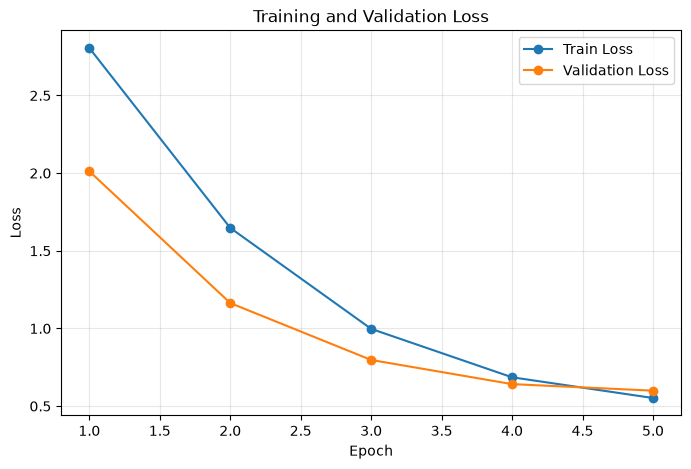

In [ ]:
# Training curve: Loss

epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

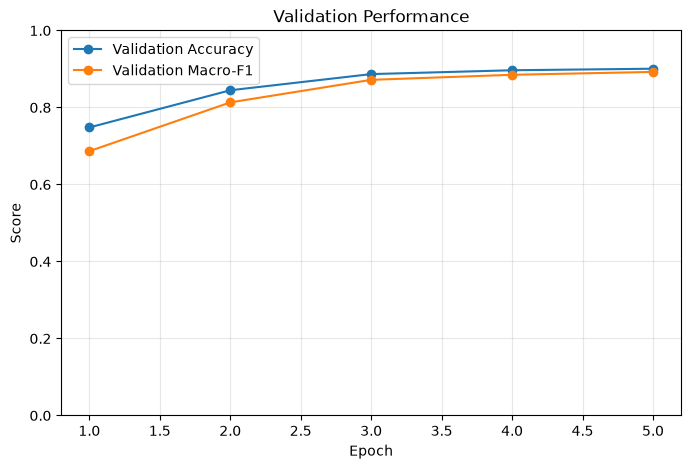

In [ ]:
# Validation accuracy and macro-F1

plt.figure(figsize=(8, 5))

plt.plot(epochs, history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.plot(epochs, history["val_f1"], marker="o", label="Validation Macro-F1")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Performance")

plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# Load best model

model.load_state_dict(torch.load("best_bert_mlp.pt", map_location=DEVICE))
model.eval()


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,),

In [ ]:
# Final test set evaluation

test_results = evaluate(model, test_loader, criterion)

print("\nFinal Test Results")
print(f"Test Loss:       {test_results['loss']:.4f}")
print(f"Test Accuracy:   {test_results['accuracy']:.4f}")
print(f"Macro Precision: {test_results['precision']:.4f}")
print(f"Macro Recall:    {test_results['recall']:.4f}")
print(f"Macro F1:        {test_results['f1']:.4f}")


# Classification report

report = classification_report(
    test_results["labels"], test_results["predictions"],
    labels=list(range(NUM_LABELS)),
    target_names=label_names,
    digits=4,
    zero_division=0
)

print("\nClassification Report:")
print(report)


# Classification report as DataFrame

report_dict = classification_report(
    test_results["labels"], test_results["predictions"],
    labels=list(range(NUM_LABELS)),
    target_names=label_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()
class_report_df = report_df.loc[label_names].copy()

class_report_df["label_id"] = range(NUM_LABELS)

class_report_df = class_report_df[
    ["label_id", "precision", "recall", "f1-score", "support"]
]

print("\nLowest-performing classes:")
display(class_report_df.sort_values("f1-score").head(20))



Final Test Results
Test Loss:       0.6293
Test Accuracy:   0.9003
Macro Precision: 0.9087
Macro Recall:    0.9003
Macro F1:        0.8982

Classification Report:
                                                  precision    recall  f1-score   support

                                activate_my_card     0.9744    0.9500    0.9620        40
                                       age_limit     0.9756    1.0000    0.9877        40
                         apple_pay_or_google_pay     1.0000    1.0000    1.0000        40
                                     atm_support     1.0000    0.9500    0.9744        40
                                automatic_top_up     1.0000    0.9000    0.9474        40
         balance_not_updated_after_bank_transfer     0.8378    0.7750    0.8052        40
balance_not_updated_after_cheque_or_cash_deposit     1.0000    0.9500    0.9744        40
                         beneficiary_not_allowed     0.8919    0.8250    0.8571        40
                         

,label_id,precision,recall,f1-score,support
virtual_card_not_working,72,1.000000,0.225,0.367347,40.0
get_disposable_virtual_card,37,0.622642,0.825,0.709677,40.0
why_verify_identity,74,0.750000,0.675,0.710526,40.0
verify_my_identity,69,0.727273,0.800,0.761905,40.0
topping_up_by_card,62,0.789474,0.750,0.769231,40.0
getting_virtual_card,40,0.672414,0.975,0.795918,40.0
balance_not_updated_after_bank_transfer,5,0.837838,0.775,0.805195,40.0
card_acceptance,10,1.000000,0.675,0.805970,40.0
transfer_into_account,65,0.804878,0.825,0.814815,40.0
fiat_currency_support,36,0.864865,0.800,0.831169,40.0


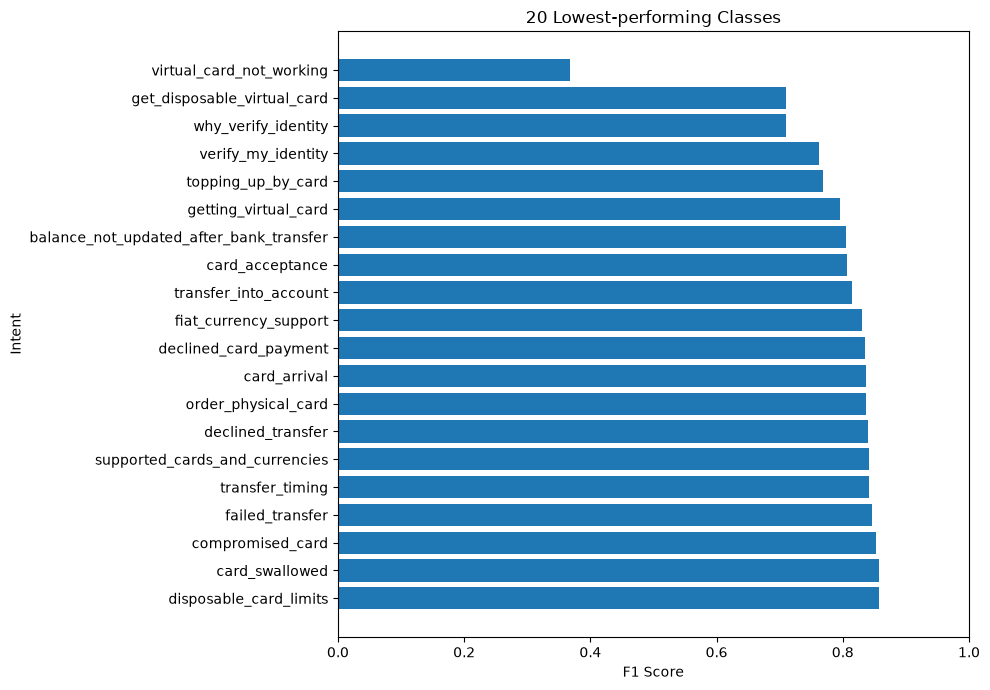

In [ ]:
# Visualize lowest-performing classes

lowest_f1 = class_report_df.sort_values("f1-score").head(20)

plt.figure(figsize=(10, 7))
plt.barh(lowest_f1.index, lowest_f1["f1-score"])

plt.xlabel("F1 Score")
plt.ylabel("Intent")
plt.title("20 Lowest-performing Classes")
plt.xlim(0, 1)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

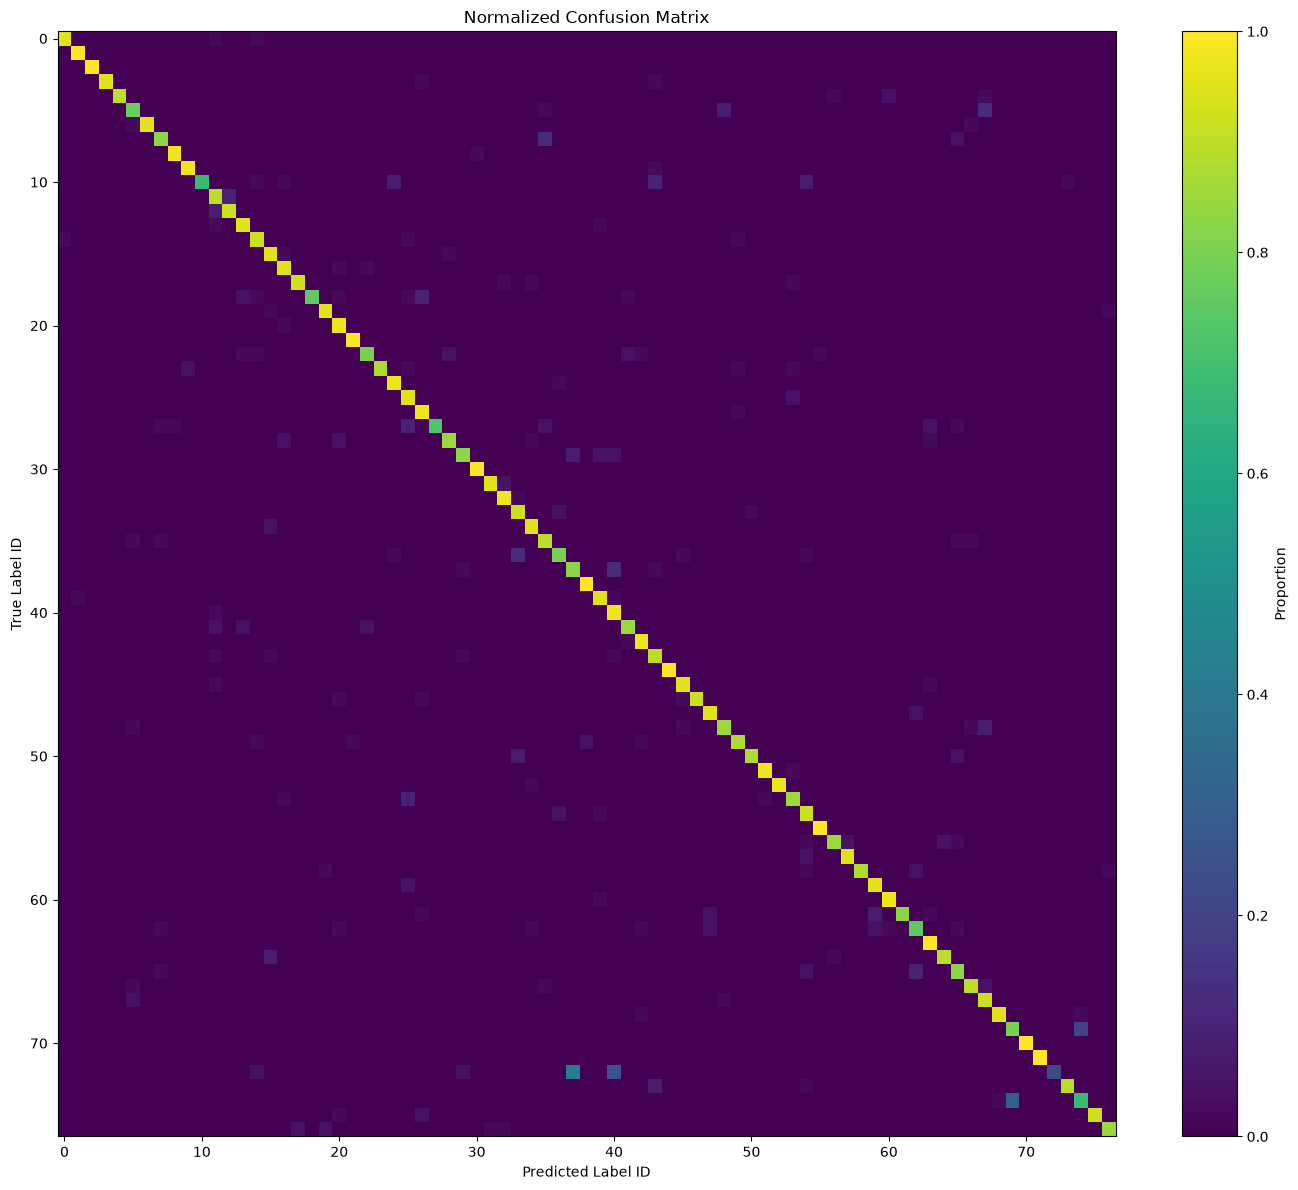

In [ ]:
# Normalized confusion matrix

cm_normalized = confusion_matrix(
    test_results["labels"], test_results["predictions"],
    labels=list(range(NUM_LABELS)),
    normalize="true"
)

plt.figure(figsize=(14, 12))
plt.imshow(cm_normalized, interpolation="nearest", aspect="auto")

plt.colorbar(label="Proportion")
plt.xlabel("Predicted Label ID")
plt.ylabel("True Label ID")
plt.title("Normalized Confusion Matrix")

plt.tight_layout()
plt.show()


In [ ]:
# Find most common confusion pairs

cm_raw = confusion_matrix(
    test_results["labels"], test_results["predictions"],
    labels=list(range(NUM_LABELS))
)

confusion_pairs = []

for true_label in range(NUM_LABELS):
    for pred_label in range(NUM_LABELS):
        if true_label == pred_label:
            continue

        count = cm_raw[true_label, pred_label]

        if count > 0:
            confusion_pairs.append({
                "true_label_id": true_label,
                "true_label": label2meaning[true_label],
                "pred_label_id": pred_label,
                "pred_label": label2meaning[pred_label],
                "count": int(count)
            })

confusion_df = pd.DataFrame(confusion_pairs)
confusion_df = confusion_df.sort_values("count", ascending=False).reset_index(drop=True)

print("\nMost common confusion pairs:")
display(confusion_df.head(30))


Most common confusion pairs:


,true_label_id,true_label,pred_label_id,pred_label,count
0,72,virtual_card_not_working,37,get_disposable_virtual_card,17
1,74,why_verify_identity,69,verify_my_identity,12
2,72,virtual_card_not_working,40,getting_virtual_card,10
3,69,verify_my_identity,74,why_verify_identity,8
4,5,balance_not_updated_after_bank_transfer,67,transfer_timing,5
5,36,fiat_currency_support,33,exchange_via_app,5
6,37,get_disposable_virtual_card,40,getting_virtual_card,5
7,7,beneficiary_not_allowed,35,failed_transfer,5
8,11,card_arrival,12,card_delivery_estimate,4
9,18,card_swallowed,26,declined_cash_withdrawal,4
